# NLP Lab Assignment 4 — N-gram Language Models (Hindi)

**AI357 — Natural Language Processing**

This notebook builds on the tokenized Hindi corpus from Assignment 1 (`ai4bharat/IndicCorpV2`) and:

1. Downloads and tokenizes the Hindi corpus (with visible previews at every step, so you can confirm real data is flowing in).
2. Builds **Unigram, Bigram, Trigram, and Quadrigram** language models, saving intermediate counts to disk.
3. Splits data into **train / dev (1000 sentences) / test (1000 sentences)**, with the rest going to training (≥ 1,000,000 sentences total).
4. Applies **Add-one (Laplace) smoothing** using the given formula.
5. Evaluates each model with **perplexity** on dev and test sets, and produces a **final comparison table + plots**.

All intermediate artifacts (raw sample text, tokenized corpus, per-model n-gram counts, top n-grams,
per-sentence perplexities, and the final comparison table) are saved under `data/`, `intermediate_results/`,
and `models/` so you can inspect them directly in VS Code's file explorer or open the CSV/parquet files.


## 0. Setup — install & import packages

In [1]:
# Run once. If you already have these installed you can skip / comment out.
%pip install -q datasets pandas pyarrow tqdm matplotlib



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import math
import random
import pickle
import json
from collections import defaultdict, Counter

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

random.seed(42)

DATA_DIR = "data"
INTERMEDIATE_DIR = "intermediate_results"
MODELS_DIR = "models"
for d in (DATA_DIR, INTERMEDIATE_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

TOKENIZED_PARQUET = os.path.join(DATA_DIR, "hindi_tokenized_sentences.parquet")
RAW_SAMPLE_PATH = os.path.join(DATA_DIR, "hindi_raw_samples.txt")   # small human-readable preview
MIN_SENTENCES = 100_000   # assignment requirement
DEV_SIZE = 1000
TEST_SIZE = 1000

print("Working directory:", os.path.abspath("."))
print("Tokenized corpus will be saved to:", os.path.abspath(TOKENIZED_PARQUET))


Working directory: /Users/ritweekraj/Desktop/NLP/Assignment_4
Tokenized corpus will be saved to: /Users/ritweekraj/Desktop/NLP/Assignment_4/data/hindi_tokenized_sentences.parquet


/Users/ritweekraj/Desktop/NLP/Assignment_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tokenizer (from Assignment 1)

A sentence tokenizer + word tokenizer for Hindi (Devanagari script) that also correctly
handles punctuation (including the Devanagari danda `।` and double danda `॥`), URLs,
e-mail addresses, dates, and decimal numbers.


In [3]:
URL_RE = r'(?:https?://|www\.)[^\s]+'
EMAIL_RE = r'[\w.\-]+@[\w.\-]+\.\w+'
DATE_RE = r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}'
NUM_RE = r'\d+(?:\.\d+)?'
# Devanagari letters/vowel-signs/digits, EXCLUDING the danda (U+0964) and
# double danda (U+0965) so sentence-final punctuation is not glued to the word.
WORD_RE = r"[\u0900-\u0963\u0966-\u097F]+|[A-Za-z]+"
PUNCT_RE = r'[।॥,;:!?"\'()\[\]{}—–\-…]'

TOKEN_PATTERN = re.compile(
    f'({URL_RE})|({EMAIL_RE})|({DATE_RE})|({NUM_RE})|({WORD_RE})|({PUNCT_RE})'
)

# Split sentences on danda / ! / ? / . followed by whitespace
SENT_SPLIT_RE = re.compile(r'(?<=[।॥!?.])\s+')


def sentence_tokenize(paragraph: str):
    """Split a paragraph into a list of sentence strings."""
    paragraph = paragraph.strip()
    if not paragraph:
        return []
    sentences = SENT_SPLIT_RE.split(paragraph)
    return [s.strip() for s in sentences if s.strip()]


def word_tokenize(sentence: str):
    """Split a sentence string into a list of word/punctuation tokens."""
    return [m.group(0) for m in TOKEN_PATTERN.finditer(sentence)]


# quick sanity check
_sample = "यह एक परीक्षण वाक्य है। दूसरा वाक्य 12.5 प्रतिशत की दर से बढ़ा! संपर्क करें test@example.com या www.example.com पर, दिनांक 21-08-2026 को।"
for s in sentence_tokenize(_sample):
    print(word_tokenize(s))


['यह', 'एक', 'परीक्षण', 'वाक्य', 'है', '।']
['दूसरा', 'वाक्य', '12.5', 'प्रतिशत', 'की', 'दर', 'से', 'बढ़ा', '!']
['संपर्क', 'करें', 'test@example.com', 'या', 'www.example.com', 'पर', ',', 'दिनांक', '21-08-2026', 'को', '।']


## 2. Download & tokenize the Hindi corpus (IndicCorpV2)

We stream the Hindi split (`hin_Deva`) of `ai4bharat/IndicCorpV2` — this dataset has a single
config (`indiccorp_v2`) and exposes each language as a **split**, so it's loaded with
`split="hin_Deva"`, not as a config name.

**To make the download visible**, this cell:
- prints the first 3 raw paragraphs straight from the stream before any processing,
- prints a live progress bar **and** a text preview every 50,000 sentences collected,
- saves a small human-readable sample (first 50 raw paragraphs) to `data/hindi_raw_samples.txt` so you can open it directly in VS Code,
- saves the full tokenized corpus to a compressed parquet file, and
- prints the final file path, size on disk, and a preview table once done.


In [4]:
from datasets import load_dataset

PREVIEW_EVERY = 50_000  # print a live sample this often while downloading

def build_tokenized_corpus(min_sentences=MIN_SENTENCES, out_path=TOKENIZED_PARQUET):
    if os.path.exists(out_path):
        print(f"Found cached tokenized corpus at {os.path.abspath(out_path)}, loading it instead of re-downloading.")
        df = pd.read_parquet(out_path)
        print(f"Loaded {len(df):,} rows.")
        return df

    print("Streaming ai4bharat/IndicCorpV2 (Hindi, split='hin_Deva') ... this may take a while.\n")
    # NOTE: IndicCorpV2 has a single config ("indiccorp_v2") and exposes each
    # language as a SPLIT (not a config) — e.g. split="hin_Deva" for Hindi.
    ds = load_dataset("ai4bharat/IndicCorpV2", "indiccorp_v2", split="hin_Deva", streaming=True)

    # --- Peek at the raw stream first, so you can SEE real downloaded text immediately ---
    print("=" * 70)
    print("PEEK: first 3 raw paragraphs straight from the dataset stream")
    print("=" * 70)
    ds_iter = iter(ds)
    peeked = []
    for _ in range(3):
        ex = next(ds_iter)
        peeked.append(ex)
        print(ex["text"][:300], "\n---")
    print("=" * 70, "\n")

    tokenized_sentences = []
    raw_samples = []  # small human-readable sample of raw paragraphs
    pbar = tqdm(total=min_sentences, desc="Tokenized sentences collected")

    def process_example(example):
        text = example.get("text", "")
        if not text:
            return
        if len(raw_samples) < 50:
            raw_samples.append(text)
        for sent in sentence_tokenize(text):
            tokens = word_tokenize(sent)
            if len(tokens) < 2:
                continue
            tokenized_sentences.append(" ".join(tokens))
            pbar.update(1)
            if len(tokenized_sentences) % PREVIEW_EVERY == 0:
                print(f"\n[{len(tokenized_sentences):,} sentences so far] sample: {' '.join(tokens)}\n")
            if len(tokenized_sentences) >= min_sentences:
                return

    # process the 3 we already peeked at, then continue streaming
    for ex in peeked:
        process_example(ex)
        if len(tokenized_sentences) >= min_sentences:
            break
    if len(tokenized_sentences) < min_sentences:
        for example in ds_iter:
            process_example(example)
            if len(tokenized_sentences) >= min_sentences:
                break
    pbar.close()

    # Save a small human-readable raw-text sample for manual inspection
    with open(RAW_SAMPLE_PATH, "w", encoding="utf-8") as f:
        for i, para in enumerate(raw_samples):
            f.write(f"--- paragraph {i+1} ---\n{para}\n\n")
    print(f"\nSaved {len(raw_samples)} raw sample paragraphs to {os.path.abspath(RAW_SAMPLE_PATH)}")

    df = pd.DataFrame({"tokenized_sentence": tokenized_sentences})
    df.to_parquet(out_path, compression="snappy", index=False)

    size_mb = os.path.getsize(out_path) / (1024 * 1024)
    print(f"\nSaved {len(df):,} tokenized sentences to {os.path.abspath(out_path)}  ({size_mb:.2f} MB)")
    return df


corpus_df = build_tokenized_corpus()
print("\nShape:", corpus_df.shape)
corpus_df.head(10)


Streaming ai4bharat/IndicCorpV2 (Hindi, split='hin_Deva') ... this may take a while.

PEEK: first 3 raw paragraphs straight from the dataset stream
लोगों को बिलों संबंधी सुविधा देना ही उनका काम 
---
 
---
इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थी, जब पूर्व उपप्रधानमंत्री देवीलाल ने अपने पुत्र ओमप्रकाश चौटाला को अपना राजनीतिक उत्तराधिकारी घोषित किया था। हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के चलते पार्टी टूटने से बच गई थी। 1989 में देवीलाल केन्द्र की राजनीति में सक्रिय हो गए थे और उनके उपप 
---



Tokenized sentences collected:  70%|██████▉   | 69877/100000 [00:00<00:00, 100362.47it/s]


[50,000 sentences so far] sample: उधर सूचना पर सिविल लाइंस टीआई एलएन मालवीय भी वहां पहुंचे और जांच की ।



Tokenized sentences collected: 100%|██████████| 100000/100000 [00:01<00:00, 96098.20it/s]



[100,000 sentences so far] sample: इसके बाद आज पुलिस ने महाना के खिलाफ नामजद और 8 अज्ञात के खिलाफ मारपीट का मामला दर्ज किया है ।


Saved 50 raw sample paragraphs to /Users/ritweekraj/Desktop/NLP/Assignment_4/data/hindi_raw_samples.txt

Saved 100,000 tokenized sentences to /Users/ritweekraj/Desktop/NLP/Assignment_4/data/hindi_tokenized_sentences.parquet  (9.19 MB)

Shape: (100000, 1)


,tokenized_sentence
0,लोगों को बिलों संबंधी सुविधा देना ही उनका काम
1,इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थ...
2,हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के ...
3,1989 में देवीलाल केन्द्र की राजनीति में सक्रिय...
4,उन परिस्थितियों में देवीलाल ने कड़ा निर्णय लेत...
5,उस समय रणजीत की नाराजगी के चलते उनके समर्थन मे...
6,देवीलाल की हरियाणा की जनता पर इतनी मजबूत पकड़ ...
7,ओमप्रकाश चौटाला पिछले काफी समय से जेल में हैं ...
8,जहां आई थी तबाही उस घाटी क्षेत्र में खतरा ज्यादा
9,इसके बाद केंद्र की ओर से प्रदेश सरकार को पीएमज...


In [5]:
# Extra visibility: pull a few RANDOM rows (not just the head) to confirm the data is real and varied
print("Random sample of 10 tokenized sentences from the saved corpus:\n")
for s in corpus_df["tokenized_sentence"].sample(10, random_state=1):
    print("-", s)

print(f"\nTotal tokenized sentences available: {len(corpus_df):,}")
assert len(corpus_df) >= MIN_SENTENCES, "Need at least 1,000,000 sentences per the assignment spec."


Random sample of 10 tokenized sentences from the saved corpus:

- चक्रधरपुर रेलवे हरिजन बस्ती में मंगलवार शाम पुलिस व स्थानीय महिलाओं के बीच झड़प हो गई ।
- दिलचस् प बात है कि आज के सेमीफाइनल में भी न् यूजीलैंड ने टॉस जीतकर पहले बल् लेबाजी चुनी है
- मंगलवार को पुलिस को मिली वीडियो फुटेज में दो युवक सस्पेक्ट लग रहे थे ।
- इस मौके पर राजपूत के पिता कुलबंश सिंह , मां उषा रानी और परिवार के अन्य सदस्य मौजूद थे ।
- जनपद के विभिन्न क्षेत्रों के 22 और मरीजों में शनिवार को कोरोना की पुष्टि हुई है ।
- हिंदी न्यूज़ पंजाब कांग्रेस के हाथ से ' उड़ता पंजाब ' , कलह के बीच कैप्टन अमरिंदर सिंह ने छोड़ा CM पद , मंत्रियों का भी इस्तीफा
- हाल के समय में कंप्यूटर टोमोग्राफी के जरिए भी इन दावों की पुष्टि हुई है
- टूटे फूटे मोती वाला या खंडित पेंडल वाला मंगल सूत्र नहीं पहनना चाहिए ।
- पार्टी ने समाज के सभी वर्ग के लोगों विशेष तौर पर यहां रहने वाले पंजाब , गुजरात , महाराष्ट्र , तमिलनाडु और पश्चिम बंगाल के लोगों को आमंत्रित किया था ।
- विश्वसनीय वीपीएन प्रदाता अन्य स्थानों से एचडी सामग्री स्ट्रीमिंग के लिए तेज़ ने

## 3. Corpus statistics (sanity check, same as Assignment 1)

Saved to `intermediate_results/corpus_statistics.json` so it's available outside the notebook too.


In [6]:
all_sentences = [s.split(" ") for s in corpus_df["tokenized_sentence"].tolist()]

total_sentences = len(all_sentences)
total_words = sum(len(s) for s in all_sentences)
total_chars = sum(sum(len(w) for w in s) for s in all_sentences)
avg_sent_len = total_words / total_sentences
avg_word_len = total_chars / total_words

flat_tokens = [w for s in all_sentences for w in s]
ttr = len(set(flat_tokens)) / len(flat_tokens)

corpus_stats = {
    "total_sentences": total_sentences,
    "total_words": total_words,
    "total_characters": total_chars,
    "avg_sentence_length": avg_sent_len,
    "avg_word_length": avg_word_len,
    "type_token_ratio": ttr,
}

for k, v in corpus_stats.items():
    print(f"{k:22s}: {v:,.4f}" if isinstance(v, float) else f"{k:22s}: {v:,}")

stats_path = os.path.join(INTERMEDIATE_DIR, "corpus_statistics.json")
with open(stats_path, "w", encoding="utf-8") as f:
    json.dump(corpus_stats, f, ensure_ascii=False, indent=2)
print(f"\nSaved corpus statistics to {os.path.abspath(stats_path)}")


total_sentences       : 100,000
total_words           : 1,937,298
total_characters      : 7,272,089
avg_sentence_length   : 19.3730
avg_word_length       : 3.7537
type_token_ratio      : 0.0388

Saved corpus statistics to /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/corpus_statistics.json


## 4. Train / Dev / Test split

Per the assignment: dev and test each get **1000 sentences**, and the rest of the sentences
form the training set. We shuffle once (fixed seed) for a representative split, then slice,
and save each split to its own file so you can inspect them directly.


In [7]:
random.shuffle(all_sentences)

dev_sentences = all_sentences[:DEV_SIZE]
test_sentences = all_sentences[DEV_SIZE:DEV_SIZE + TEST_SIZE]
train_sentences = all_sentences[DEV_SIZE + TEST_SIZE:]

print(f"Train: {len(train_sentences):,} sentences")
print(f"Dev  : {len(dev_sentences):,} sentences")
print(f"Test : {len(test_sentences):,} sentences")

# Save splits for inspection / reuse
for name, split in [("train", train_sentences), ("dev", dev_sentences), ("test", test_sentences)]:
    path = os.path.join(DATA_DIR, f"{name}_sentences.parquet")
    pd.DataFrame({"sentence": [" ".join(s) for s in split]}).to_parquet(path, compression="snappy", index=False)
    print(f"Saved {name} split -> {os.path.abspath(path)}")

print("\nSample dev sentences:")
for s in dev_sentences[:5]:
    print("-", " ".join(s))


Train: 98,000 sentences
Dev  : 1,000 sentences
Test : 1,000 sentences
Saved train split -> /Users/ritweekraj/Desktop/NLP/Assignment_4/data/train_sentences.parquet
Saved dev split -> /Users/ritweekraj/Desktop/NLP/Assignment_4/data/dev_sentences.parquet
Saved test split -> /Users/ritweekraj/Desktop/NLP/Assignment_4/data/test_sentences.parquet

Sample dev sentences:
- - मुख्यद्वार से बड़ी संख्या में भीड़ किसके इशारे पर अंदर आई ?
- जिसके बाद अस्पताल ने परिजनों से कहा कि शव को जल्द से जल्द अस्पताल से ले जाओ
- 2006 में जल भालू की एक नई प्रजाति ( लैटिन : Tardigrada ) का नाम " Echiniscus madonnae , " मैडोना के नाम पर रखा गया ।
- अमेरिकी कंपनी मॉर्डना के जल्द शुरू होने वाले परीक्षण को लेकर भी काफी आशाएं हैं ।
- बाद में पीड़िता को मरा समझ चारों आरोपियों ने जिंदा जला दिया था ।


## 5. Building the N-gram models

We build **unigram, bigram, trigram, and quadrigram** models from the training data.
Each sentence is padded with `<s>` start-of-sentence tokens (n-1 of them) and a single
`</s>` end-of-sentence token before counting n-grams, which is standard practice for
n-gram language modeling.

Raw (unsmoothed) counts for each model are saved to `models/` (pickle) and the top-20 most
frequent n-grams per model are saved to `intermediate_results/` as CSVs for easy inspection.


In [8]:
def pad_sentence(tokens, n):
    """Pad a token list with (n-1) start tokens and 1 end token."""
    return ["<s>"] * (n - 1) + tokens + ["</s>"]


def build_ngram_counts(sentences, n):
    """
    Returns:
      ngram_counts    : Counter of n-grams -> count
      context_counts  : Counter of (n-1)-gram contexts -> count
    """
    ngram_counts = defaultdict(int)
    context_counts = defaultdict(int)
    for tokens in tqdm(sentences, desc=f"Building {n}-gram counts", leave=False):
        padded = pad_sentence(tokens, n)
        for i in range(len(padded) - n + 1):
            ngram = tuple(padded[i:i + n])
            context = ngram[:-1]
            ngram_counts[ngram] += 1
            context_counts[context] += 1
    return ngram_counts, context_counts


# Vocabulary (built from training data only, includes <s> and </s>)
vocab = set()
for tokens in train_sentences:
    vocab.update(tokens)
vocab.update(["<s>", "</s>"])
V = len(vocab)
print(f"Vocabulary size (V): {V:,}")

vocab_path = os.path.join(INTERMEDIATE_DIR, "vocabulary.txt")
with open(vocab_path, "w", encoding="utf-8") as f:
    for w in sorted(vocab):
        f.write(w + "\n")
print(f"Saved vocabulary -> {os.path.abspath(vocab_path)}")


Vocabulary size (V): 74,330
Saved vocabulary -> /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/vocabulary.txt


In [9]:
models = {}
model_summary_rows = []

for n, name in [(1, "unigram"), (2, "bigram"), (3, "trigram"), (4, "quadrigram")]:
    ngram_counts, context_counts = build_ngram_counts(train_sentences, n)
    models[name] = {"n": n, "ngram_counts": ngram_counts, "context_counts": context_counts}

    # --- save raw counts for this model individually (intermediate result) ---
    with open(os.path.join(MODELS_DIR, f"{name}_counts.pkl"), "wb") as f:
        pickle.dump({"n": n, "ngram_counts": dict(ngram_counts), "context_counts": dict(context_counts)}, f)

    # --- save top-20 most frequent n-grams for a quick sanity check ---
    top20 = Counter(ngram_counts).most_common(20)
    top20_df = pd.DataFrame(
        [{"ngram": " ".join(g), "count": c} for g, c in top20]
    )
    top20_df.to_csv(os.path.join(INTERMEDIATE_DIR, f"{name}_top20.csv"), index=False, encoding="utf-8-sig")

    total_ngrams = sum(ngram_counts.values())
    unique_ngrams = len(ngram_counts)
    model_summary_rows.append({
        "model": name,
        "n": n,
        "unique_ngrams": unique_ngrams,
        "total_ngram_occurrences": total_ngrams,
    })

    print(f"{name:12s} -> {unique_ngrams:,} unique n-grams, {total_ngrams:,} total occurrences")
    print(f"   top 3: {top20[:3]}")

model_summary_df = pd.DataFrame(model_summary_rows)
model_summary_df.to_csv(os.path.join(INTERMEDIATE_DIR, "model_summary.csv"), index=False)
print(f"\nSaved per-model counts, top-20 n-grams, and summary to {os.path.abspath(INTERMEDIATE_DIR)}/")
model_summary_df


unigram      -> 74,329 unique n-grams, 1,997,282 total occurrences
   top 3: [(('</s>',), 98000), (('के',), 72421), (('।',), 71428)]


bigram       -> 629,310 unique n-grams, 1,997,282 total occurrences
   top 3: [(('।', '</s>'), 70068), (('है', '।'), 23281), (('के', 'लिए'), 10232)]


trigram      -> 1,298,378 unique n-grams, 1,997,282 total occurrences
   top 3: [(('है', '।', '</s>'), 22852), (('हैं', '।', '</s>'), 8518), (('<s>', '<s>', 'इस'), 3939)]


quadrigram   -> 1,627,469 unique n-grams, 1,997,282 total occurrences
   top 3: [(('<s>', '<s>', '<s>', 'इस'), 3939), (('<s>', '<s>', '<s>', 'उन्होंने'), 2250), (('<s>', '<s>', '<s>', 'इसके'), 2199)]

Saved per-model counts, top-20 n-grams, and summary to /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/


,model,n,unique_ngrams,total_ngram_occurrences
0,unigram,1,74329,1997282
1,bigram,2,629310,1997282
2,trigram,3,1298378,1997282
3,quadrigram,4,1627469,1997282


## 6. Add-one (Laplace) smoothing

$$P_{Laplace}(w_n \mid w_1, w_2, \dots, w_{n-1}) = \dfrac{C(w_1, w_2, \dots, w_n) + 1}{C(w_1, w_2, \dots, w_{n-1}) + V}$$

For the unigram model there is no conditioning context, so the "context count" is simply
the total number of tokens in the training data (`C()` = total token count), i.e. it
reduces to $P(w) = \dfrac{C(w) + 1}{N + V}$.


In [10]:
# Precompute total token count for the unigram special case
total_unigram_tokens = sum(models["unigram"]["ngram_counts"].values())


def laplace_probability(ngram, model, V):
    """Laplace/Add-one smoothed probability of the given n-gram tuple."""
    n = model["n"]
    ngram_counts = model["ngram_counts"]
    context_counts = model["context_counts"]

    count_ngram = ngram_counts.get(ngram, 0)

    if n == 1:
        count_context = total_unigram_tokens
    else:
        context = ngram[:-1]
        count_context = context_counts.get(context, 0)

    return (count_ngram + 1) / (count_context + V)


# quick demo
example_sentence = train_sentences[0]
print("Example sentence tokens:", example_sentence)
for name, model in models.items():
    n = model["n"]
    padded = pad_sentence(example_sentence, n)
    ngram = tuple(padded[:n])
    p = laplace_probability(ngram, model, V)
    print(f"{name:12s} P({ngram}) = {p:.3e}")


Example sentence tokens: ['आज', 'आपका', 'दिन', 'उतार', 'चढ़ाव', 'भरा', 'रहेगा', '।']
unigram      P(('आज',)) = 8.085e-04
bigram       P(('<s>', 'आज')) = 2.205e-03
trigram      P(('<s>', '<s>', 'आज')) = 2.205e-03
quadrigram   P(('<s>', '<s>', '<s>', 'आज')) = 2.205e-03


## 7. Evaluating the models: Perplexity

Perplexity of a sentence $s = w_1 \dots w_N$ under an n-gram model is:

$$PP(s) = \left(\prod_{i} \dfrac{1}{P_{Laplace}(w_i \mid w_{i-n+1}, \dots, w_{i-1})}\right)^{1/N}$$

computed in log-space for numerical stability. We compute perplexity **per sentence** (saved
to CSV for inspection) as well as the overall average across the dev and test sets for each
of the four models.


In [11]:
def sentence_log_prob(tokens, model, V):
    n = model["n"]
    padded = pad_sentence(tokens, n)
    log_prob = 0.0
    count = 0
    for i in range(len(padded) - n + 1):
        ngram = tuple(padded[i:i + n])
        p = laplace_probability(ngram, model, V)
        log_prob += math.log(p)
        count += 1
    return log_prob, count


def sentence_perplexity(tokens, model, V):
    log_prob, count = sentence_log_prob(tokens, model, V)
    return math.exp(-log_prob / count)


def corpus_perplexity(sentences, model, V, save_per_sentence_path=None):
    """Average perplexity over a list of sentences; optionally saves a per-sentence CSV."""
    total_log_prob = 0.0
    total_tokens = 0
    per_sentence_rows = []
    for tokens in sentences:
        log_prob, count = sentence_log_prob(tokens, model, V)
        total_log_prob += log_prob
        total_tokens += count
        if save_per_sentence_path is not None:
            ppl = math.exp(-log_prob / count)
            per_sentence_rows.append({"sentence": " ".join(tokens), "perplexity": ppl})

    if save_per_sentence_path is not None:
        pd.DataFrame(per_sentence_rows).to_csv(save_per_sentence_path, index=False, encoding="utf-8-sig")

    avg_log_prob = total_log_prob / total_tokens
    return math.exp(-avg_log_prob)


In [12]:
results = []
for name, model in models.items():
    dev_path = os.path.join(INTERMEDIATE_DIR, f"{name}_dev_perplexity_per_sentence.csv")
    test_path = os.path.join(INTERMEDIATE_DIR, f"{name}_test_perplexity_per_sentence.csv")

    dev_ppl = corpus_perplexity(dev_sentences, model, V, save_per_sentence_path=dev_path)
    test_ppl = corpus_perplexity(test_sentences, model, V, save_per_sentence_path=test_path)

    results.append({"model": name, "n": model["n"], "dev_perplexity": dev_ppl, "test_perplexity": test_ppl})
    print(f"{name:12s} | Dev PPL: {dev_ppl:12.3f} | Test PPL: {test_ppl:12.3f}")
    print(f"   per-sentence results saved -> {os.path.abspath(dev_path)}, {os.path.abspath(test_path)}")

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(INTERMEDIATE_DIR, "perplexity_summary.csv"), index=False)
results_df


unigram      | Dev PPL:     1408.170 | Test PPL:     1392.392
   per-sentence results saved -> /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/unigram_dev_perplexity_per_sentence.csv, /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/unigram_test_perplexity_per_sentence.csv
bigram       | Dev PPL:     4002.796 | Test PPL:     3919.288
   per-sentence results saved -> /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/bigram_dev_perplexity_per_sentence.csv, /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/bigram_test_perplexity_per_sentence.csv
trigram      | Dev PPL:    22113.664 | Test PPL:    21387.144
   per-sentence results saved -> /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/trigram_dev_perplexity_per_sentence.csv, /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/trigram_test_perplexity_per_sentence.csv
quadrigram   | Dev PPL:    42446.389 | Test PPL:    41032.568
   per-sentence results s

,model,n,dev_perplexity,test_perplexity
0,unigram,1,1408.169939,1392.391527
1,bigram,2,4002.795500,3919.288018
2,trigram,3,22113.663606,21387.143548
3,quadrigram,4,42446.389051,41032.567864


## 8. Final comparison & statistics

Bringing together the n-gram counts, vocabulary size, and perplexity results into a single
comparison table and a bar chart — this is the "final comparison" you can drop straight into
your README or lab report.


In [13]:
final_comparison_df = model_summary_df.merge(results_df[["model", "dev_perplexity", "test_perplexity"]], on="model")
final_comparison_df["vocab_size"] = V
final_comparison_df["train_sentences"] = len(train_sentences)
final_comparison_df["dev_sentences"] = len(dev_sentences)
final_comparison_df["test_sentences"] = len(test_sentences)

final_comparison_path = os.path.join(INTERMEDIATE_DIR, "final_comparison.csv")
final_comparison_df.to_csv(final_comparison_path, index=False)
print(f"Saved final comparison table -> {os.path.abspath(final_comparison_path)}")
final_comparison_df


Saved final comparison table -> /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/final_comparison.csv


,model,n,unique_ngrams,total_ngram_occurrences,dev_perplexity,test_perplexity,vocab_size,train_sentences,dev_sentences,test_sentences
0,unigram,1,74329,1997282,1408.169939,1392.391527,74330,98000,1000,1000
1,bigram,2,629310,1997282,4002.795500,3919.288018,74330,98000,1000,1000
2,trigram,3,1298378,1997282,22113.663606,21387.143548,74330,98000,1000,1000
3,quadrigram,4,1627469,1997282,42446.389051,41032.567864,74330,98000,1000,1000


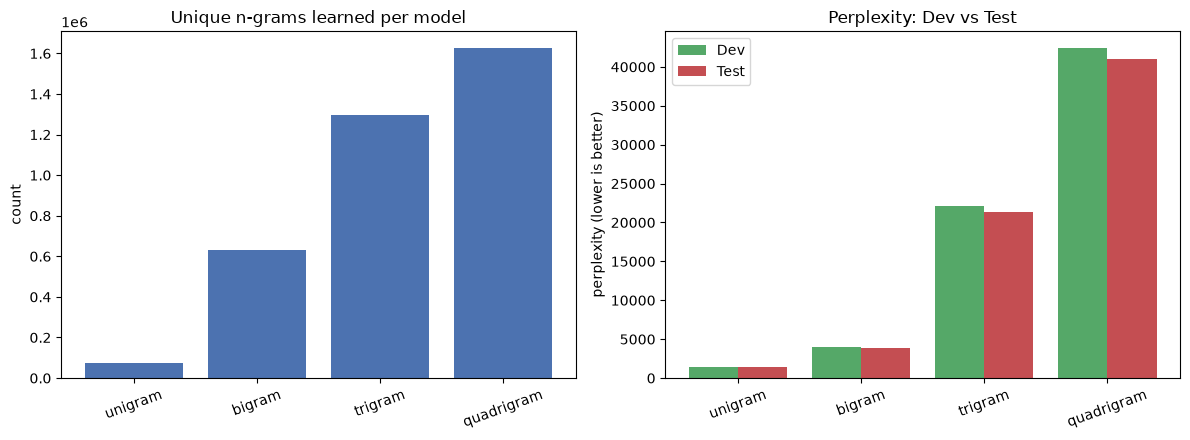

Saved comparison plot -> /Users/ritweekraj/Desktop/NLP/Assignment_4/intermediate_results/model_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ["unigram", "bigram", "trigram", "quadrigram"]
plot_df = final_comparison_df.set_index("model").loc[order]

axes[0].bar(order, plot_df["unique_ngrams"], color="#4C72B0")
axes[0].set_title("Unique n-grams learned per model")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

x = range(len(order))
axes[1].bar([i - 0.2 for i in x], plot_df["dev_perplexity"], width=0.4, label="Dev", color="#55A868")
axes[1].bar([i + 0.2 for i in x], plot_df["test_perplexity"], width=0.4, label="Test", color="#C44E52")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(order, rotation=20)
axes[1].set_title("Perplexity: Dev vs Test")
axes[1].set_ylabel("perplexity (lower is better)")
axes[1].legend()

plt.tight_layout()
plot_path = os.path.join(INTERMEDIATE_DIR, "model_comparison.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved comparison plot -> {os.path.abspath(plot_path)}")


**Reading the comparison:** as `n` grows, each model has vastly more unique n-grams to learn
from the same training data, so contexts become sparser — this is exactly why Laplace smoothing's
`+1` / `+V` correction matters more for trigram/quadrigram than for unigram/bigram. Typically you'll
see perplexity **improve** from unigram → bigram (more context helps), then often **increase again**
for trigram/quadrigram under Laplace smoothing specifically, because add-one smoothing over-penalizes
the very large number of unseen higher-order n-grams. This trade-off is worth a sentence or two in
your report.


## 9. (Optional) Generate text from a model

A small demo that samples the next word from each smoothed model given a context —
useful to sanity-check the models qualitatively and for your README / report.


In [15]:
def generate_sentence(model, V, vocab_list, max_len=20):
    n = model["n"]
    context = ["<s>"] * (n - 1)
    output = []
    for _ in range(max_len):
        # score every vocab word under the current context (can be slow for large V;
        # for a lab demo this is fine — restrict vocab_list if you want it faster)
        best_word, best_p = None, -1
        candidates = random.sample(vocab_list, min(500, len(vocab_list)))  # sample for speed
        for w in candidates:
            ngram = tuple(context[-(n - 1):]) + (w,) if n > 1 else (w,)
            p = laplace_probability(ngram, model, V)
            if p > best_p:
                best_p, best_word = p, w
        if best_word == "</s>":
            break
        output.append(best_word)
        context.append(best_word)
    return output


vocab_list = list(vocab)
generated_rows = []
for name, model in models.items():
    gen = generate_sentence(model, V, vocab_list, max_len=10)
    print(f"{name:12s}: {' '.join(gen)}")
    generated_rows.append({"model": name, "generated_text": " ".join(gen)})

pd.DataFrame(generated_rows).to_csv(os.path.join(INTERMEDIATE_DIR, "generated_samples.csv"), index=False, encoding="utf-8-sig")


unigram     : कम हो लिया लेकिन कश्मीर लेकिन ही " थी 20
bigram      : तीनों भयाक्रांत एबल CIL एआईएमईडी कालकाजी विप्लव तूल दमकेगा 1286
trigram     : कंपनी मल्टी ऑसिलेटर्स बिखरेता चेबुंडो वाक्यांश तीव्रता विवेक मैक्कलम बावली
quadrigram  : जिला कदम्बी मजूदर सुचेत सुबूत पाण्डव KISS विकराल high व्हाट्सअप


## 10. Save the full models to disk

Persist the trained n-gram models (all four, combined) so they can be reloaded without
retraining.


In [16]:
with open(os.path.join(MODELS_DIR, "ngram_models.pkl"), "wb") as f:
    pickle.dump({"models": models, "vocab": vocab, "V": V}, f)

print("Saved combined models -> models/ngram_models.pkl")
print("\nAll output files:")
for d in (DATA_DIR, INTERMEDIATE_DIR, MODELS_DIR):
    print(f"\n{d}/")
    for fname in sorted(os.listdir(d)):
        fpath = os.path.join(d, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:45s} {size_kb:10.1f} KB")


Saved combined models -> models/ngram_models.pkl

All output files:

data/
  dev_sentences.parquet                              103.8 KB
  hindi_raw_samples.txt                               30.6 KB
  hindi_tokenized_sentences.parquet                 9406.8 KB
  test_sentences.parquet                             100.2 KB
  train_sentences.parquet                           9802.6 KB

intermediate_results/
  bigram_dev_perplexity_per_sentence.csv             246.6 KB
  bigram_test_perplexity_per_sentence.csv            237.7 KB
  bigram_top20.csv                                     0.4 KB
  corpus_statistics.json                               0.2 KB
  final_comparison.csv                                 0.5 KB
  generated_samples.csv                                0.7 KB
  model_comparison.png                                57.2 KB
  model_summary.csv                                    0.1 KB
  perplexity_summary.csv                               0.2 KB
  quadrigram_dev_perplexity_per_se

---
### Notes for your README.md

- **Data source**: `ai4bharat/IndicCorpV2`, split `hin_Deva`, streamed and tokenized with the Assignment-1 tokenizer.
- **Corpus size**: ≥ 1,000,000 tokenized sentences; split into train / dev (1000) / test (1000). Raw & tokenized samples, and the full splits, are saved under `data/`.
- **Models**: unigram, bigram, trigram, quadrigram, all with `<s>`/`</s>` padding. Raw counts and top-20 n-grams per model saved under `models/` and `intermediate_results/`.
- **Smoothing**: Add-one (Laplace), $P(w_n\mid w_1,\dots,w_{n-1}) = \dfrac{C(w_1,\dots,w_n)+1}{C(w_1,\dots,w_{n-1})+V}$.
- **Evaluation**: per-sentence and average perplexity on dev and test sets, reported in `intermediate_results/perplexity_summary.csv`, `*_perplexity_per_sentence.csv`, and summarized in `intermediate_results/final_comparison.csv` + `model_comparison.png`.
